# Set up simulations and data

## read in libraries

In [1]:
import sys
sys.path.append(r"C:\GitHubRepos\APSIMTools\GraphLib")

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# graph models
from apsim_tools.graphing import (
    plot_obs_pred_by_branch,
    plot_stage_timeseries
)

from apsim_tools.style import ( 
    Colors, 
    Markers,
    Lines
)

from apsim_tools.runner import (
    load_all,
    validate_run_branches,
    to_tidy
)

## Branch and file Settings

In [2]:
# ======================
# CONFIG
# ======================
BRANCHES = {
    "master": "UoM_Wheat",
    "working": "WheatNeil",
    "working V2": "WheatHamish"
}

# ======================
# RUN CONTROL - Specify which branches to (re)run
# ======================

# Options:
RUN_BRANCHES = []                    # run nothing (use existing DBs)
#RUN_BRANCHES = list(BRANCHES.keys())   # run all branches
#RUN_BRANCHES = ["master"]
#RUN_BRANCHES = ["working"]
#RUN_BRANCHES = ["working V2"]

SIM_FILES = [
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Wheat.apsimx'),
    #Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\FAR\FAR.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Pask\PaskExperiments.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\GxExM\GxExM.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Fords2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Turretfield2024.apsimx')
]

CONFIG = {
    "branches": BRANCHES,
    "run_branches": RUN_BRANCHES,
    "sim_files": SIM_FILES,
    "repo_path": Path(r"C:\GitHubRepos\ApsimX"),
    "apsim_exe": r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe",
    "apsim_solution": r"C:\GitHubRepos\ApsimX\ApsimX.sln",
    "stage_var": "Wheat.Phenology.Stage",
    "stage_name_var": "Wheat.Phenology.CurrentStageName",
    "harvest_stage": "HarvestRipe",
    "cultivar_col": "Wheat.SowingData.Cultivar",
    "obs_table_name": "Observed",
    "pred_table_name": "AnalysisReport"
}

validate_run_branches(config=CONFIG)

## Additionl index mapping

In [3]:
# Specifiy map for cultivars to winter or spring type
Development_type={
'29B':'Spring',
'5A':'Spring',
'60A':'Spring',
'BigRed':'Winter',
'Corack':'Spring',
'Espada':'Spring',
'Gauntlet':'Spring',
'Gregory':'Spring',
'Hartog':'Spring',
'Illabo':'Winter',
'Janz':'Spring',
'Kittyhawk':'Winter',
'Mace':'Spring',
'Meering':'Spring',
'Mowhawk':'Winter',
'Osprey':'Winter',
'Rosella':'Winter',
'Scepter':'Spring',
'Scout':'Spring',
'Spitfire':'Spring',
'Stockade':'Spring',
'Sunbee':'Spring',
'Sunmaster':'Spring',
'Sunstate':'Spring',
'UOM001_3_47':'Winter',
'UOM001_9_1':'Winter',
'Wedgetail':'Winter',
'Whistler':'Winter',
'Wyalkatchem':'Spring',
'Wylah':'Winter',
'Yitpi':'Spring',
'Zanzibar':'Spring',
}

# Specify map for each experiment to project grouping
Project_group = {
    'Minnipa2014':'GxExM',
    'Minnipa2015':'GxExM',
    'Gatton2014Irrigated':'GxExM',
    'Gatton2014':'GxExM',
    'Gatton2015':'GxExM',
    'Junee2014':'GxExM',
    'Temora2015':'GxExM',
    'DookieWWHI2024':'WWHI',
    'DookieWWHI2025':'WWHI',
    'WaggaWagga2024':'WWHI',
    'WaggaWagga2025':'WWHI',
    'GrassPatch2024':'WWHI',
    'GrassPatch2025':'WWHI',
    'Turretfield2024':'WWHI',
    'Fords2025':'WWHI',
    'DookieEVA2024':'EVA',
    'DookieEVA2025':'EVA',
    'Gnarwarre2024':'EVA',
    'Gnarwarre2025':'EVA'
}

# Pack maps together ready to be inserted as indexes 
additional_index_maps = {
    "DevelopmentType": {
        "source": "Wheat.SowingData.Cultivar",
        "map": Development_type
    },
    "ProjectGroup": {
        "source": "Experiment",
        "map": Project_group
    }
}

## Write file for command line tool to apply to each .apsimx file to be run.
If you want to make standard modifications to all files run it can be done here

In [4]:
# this function writes and apply file that the CLI
def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """
    report_library = r"C:\GitHubRepos\APSIMTools\Report_lib.apsimx"
    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # Add AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    #lines.append("delete all [Report]")
    lines.append(f"add [AnalysisReport] from {report_library} to all [Zone]")

    # ---------------------------------------------
    # Remove existing ObsPred table and add HarvestObsPred to data store
    # ---------------------------------------------
    #lines.append("delete all [PredictedObserved]")
    
    lines.append("add new PredictedObserved to [DataStore] name HarvestObsPred")
    lines.append("[HarvestObsPred].PredictedTableName  = AnalysisReport")
    lines.append("[HarvestObsPred].ObservedTableName  = Observed")
    lines.append("[HarvestObsPred].FieldNameUsedForMatch  = SimulationName")
    lines.append("[HarvestObsPred].FieldName2UsedForMatch  = Wheat.Phenology.CurrentStageName")
        
    lines.append("add new PredictedObserved to DataStore name DailyObsPred")
    lines.append("[DailyObsPred].PredictedTableName  = AnalysisReport")
    lines.append("[DailyObsPred].ObservedTableName  = Observed")
    lines.append("[DailyObsPred].FieldNameUsedForMatch  = SimulationName")
    lines.append("[DailyObsPred].FieldName2UsedForMatch  = Clock.Today")
    
    # ---------------------------------------------
    # Inject Spectral model into each simulation
    # ---------------------------------------------
    lines.append("delete all [Spectral]")
    lines.append("add new Spectral to all [Zone]")
    
    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file

## Run simulations and read in raw .db data and process into tidy format

In [ ]:
# ======================
# EXECUTE PIPELINE
# ======================

# Read in raw data
raw = load_all(config=CONFIG, apply_fn=write_apply_file)

# ✅ Ensure SimulationName exists (from AnalysisReport)
if "Simulation.Name" in raw.columns:
    raw = raw.rename(columns={"Simulation.Name": "SimulationName"})

# ✅ Convert to tidy format
tidy = to_tidy(raw, config=CONFIG, additional_index_maps=additional_index_maps)

⏭ Skipping run [master]: Wheat.apsimx
Wheat.apsimx tables: ['_Factors', '_InitialConditions', 'DailyReport', 'AnalysisReport', '_Messages', 'HarvestReport', 'NDVIDailyReport', 'SowingReport', 'analysis', 'ExtraReport', 'SensibilityReport', 'ProteinDailyReport', 'ProteinReport', 'DetailedDynamicsReport', 'TerminalStressReport', '_Simulations', '_Checkpoints', '_Units', 'DailyObsPred', '_PredictedObserved', 'HarvestObsPred', 'NDVIObsPred', 'SEQObsPred', 'WAtObsPred', 'NZObsPred', 'SAObsPred', 'ObsAnalysisReport', 'Report', 'Observed', 'MaxLeafSize']

⚠️ Missing observed simulations in Wheat.apsimx: 62

⚠️ Dropping unmatched observed simulations in Wheat.apsimx: 75
✅ Obs filtered by SimulationID: 13850/14317 rows kept
⏭ Skipping run [master]: PaskExperiments.apsimx
PaskExperiments.apsimx tables: ['_Simulations', '_Checkpoints', '_Factors', '_InitialConditions', 'AnalysisReport', '_Messages', '_Units', 'HarvestObsPred', '_PredictedObserved', 'DailyObsPred', 'ObsAnalysisReport', 'DailyRepor

# Harvest predictions

## Yield

In [ ]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Grain.Wt",
    mode='harvest',
    filters = {"ProjectGroup":['WWHI']},
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by=None
)
graph.savefig("Yield WWHI.jpg")

In [ ]:
graph = plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Grain.Wt",
    mode='harvest',
    filters = {"ProjectGroup":['GxExM']},
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by=None
)
graph.savefig("Yield GxExM.jpg")

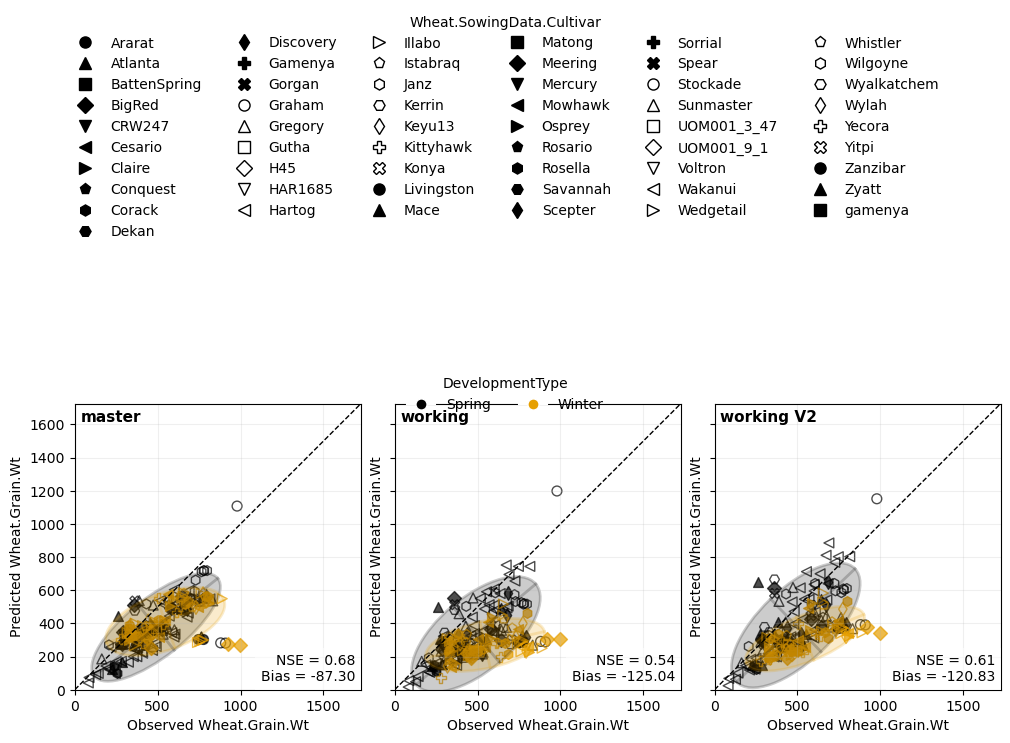

In [8]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Grain.Wt",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by=None,
    show_ellipses=True    
)
plt.show()

## Biomass

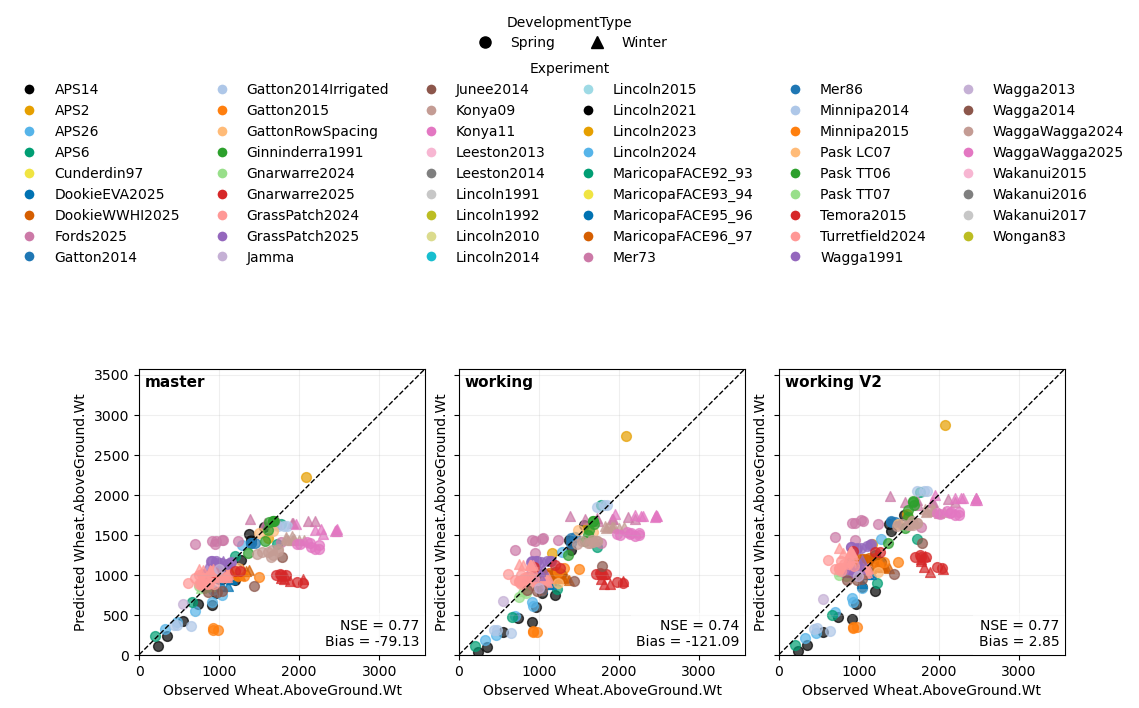

In [9]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.Wt",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by=None
)
plt.show()

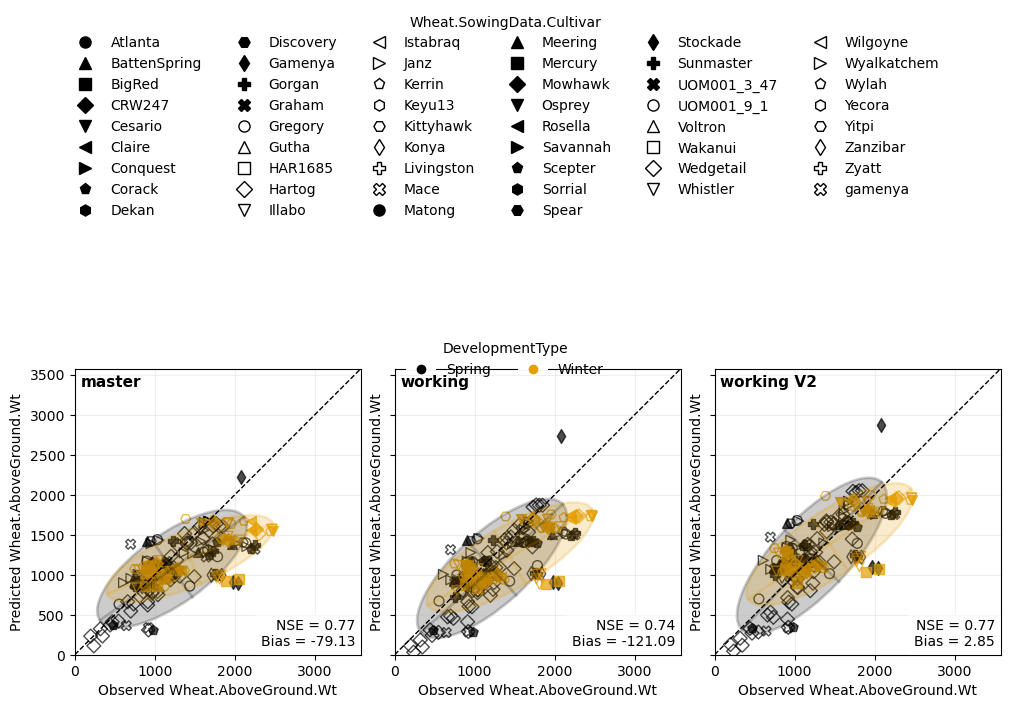

In [10]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.Wt",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by=None,
    show_ellipses=True
)
plt.show()

## Harvest Index

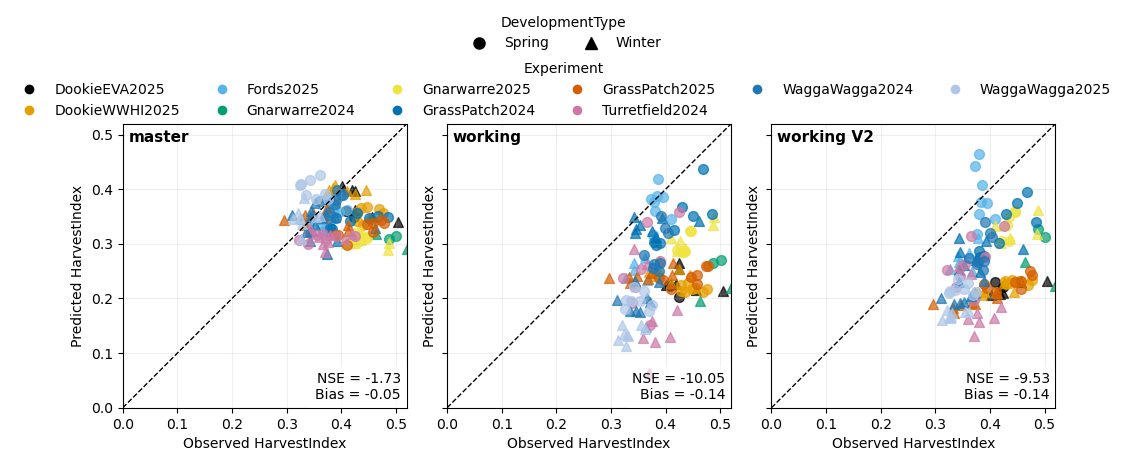

In [11]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "HarvestIndex",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by=None,
)
plt.show()

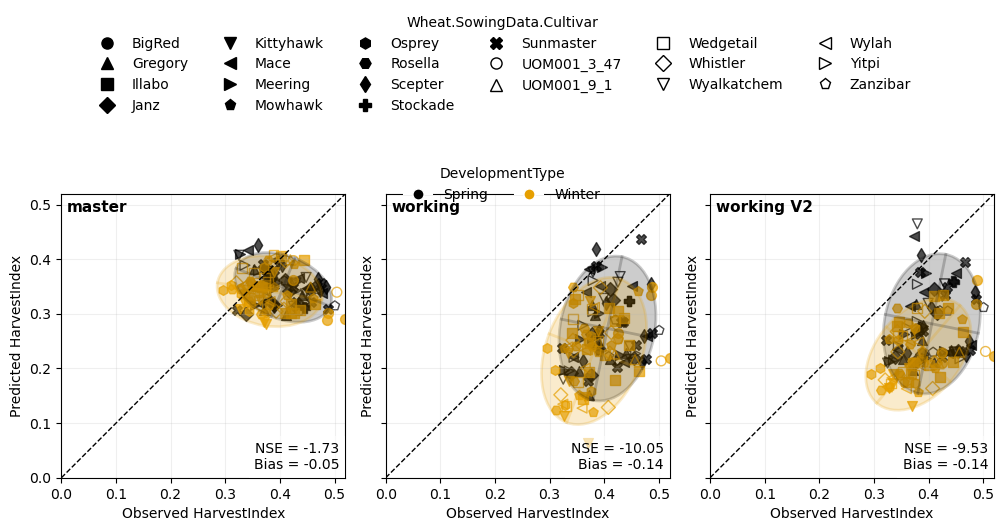

In [12]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "HarvestIndex",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "DevelopmentType",#"Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by=None,
    show_ellipses=True,
)
plt.show()

## Grian Size

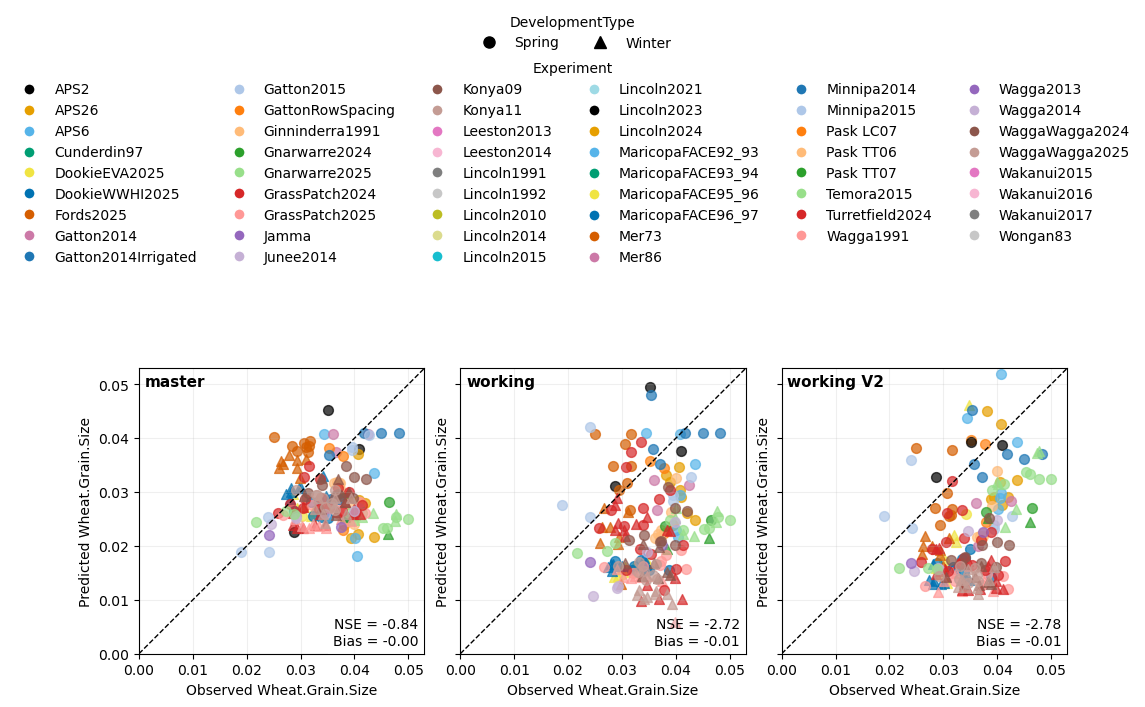

In [13]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Grain.Size",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by=None
)
plt.show()

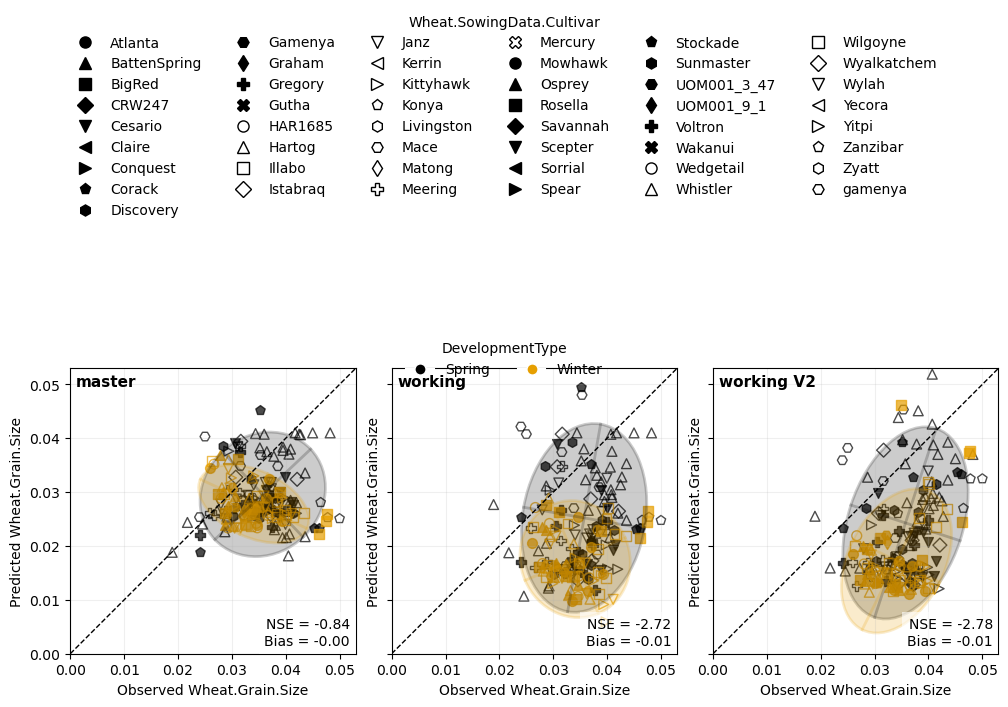

In [14]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Grain.Size",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "DevelopmentType",#"Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by=None,
    show_ellipses=True
)
plt.show()

## Grain Number

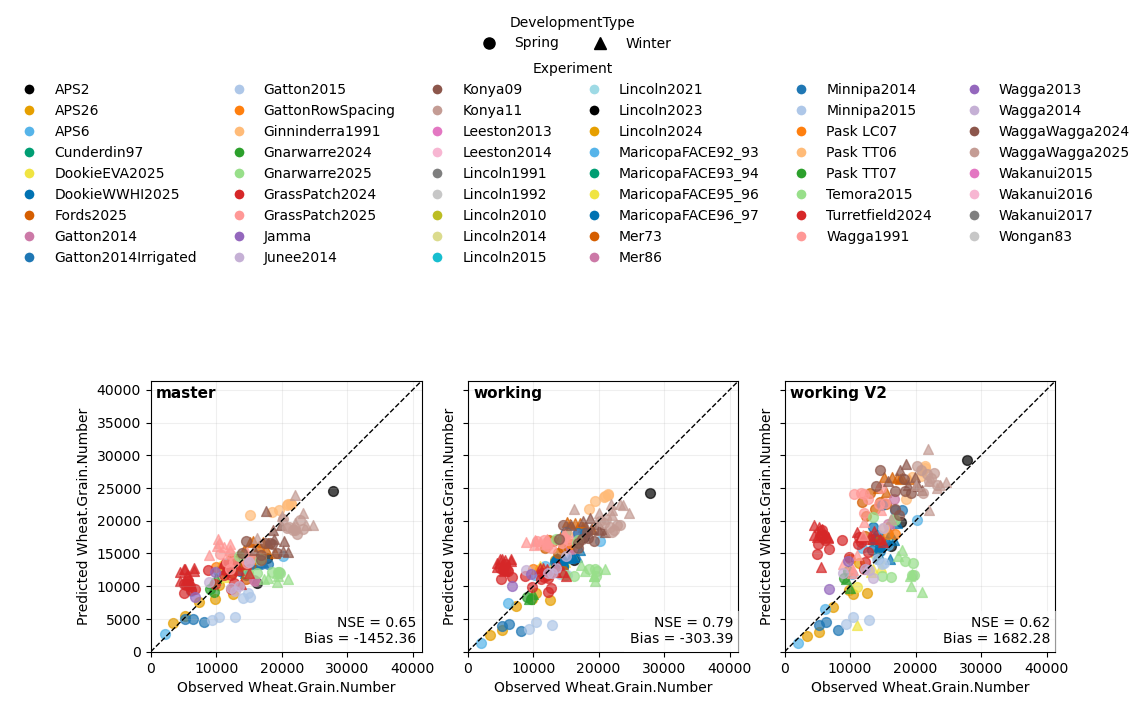

In [15]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Grain.Number",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "Experiment",
    marker_by = "DevelopmentType",#"Wheat.SowingData.Cultivar",
    size_by=None
)
plt.show()

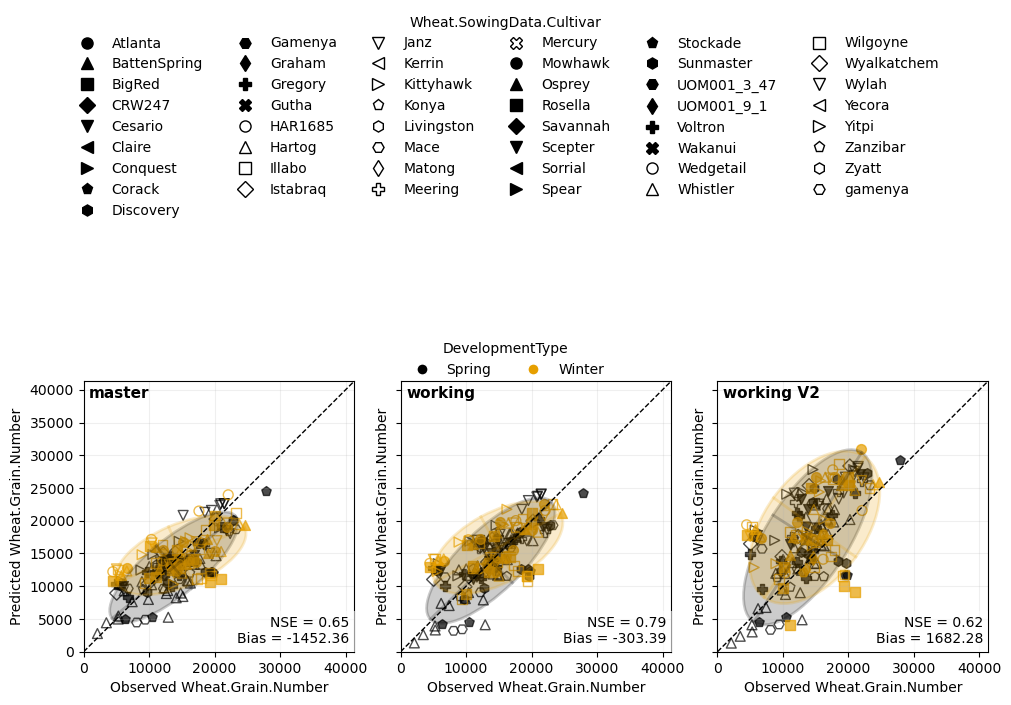

In [16]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Grain.Number",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by=None,
    show_ellipses=True
)
plt.show()

## Stem

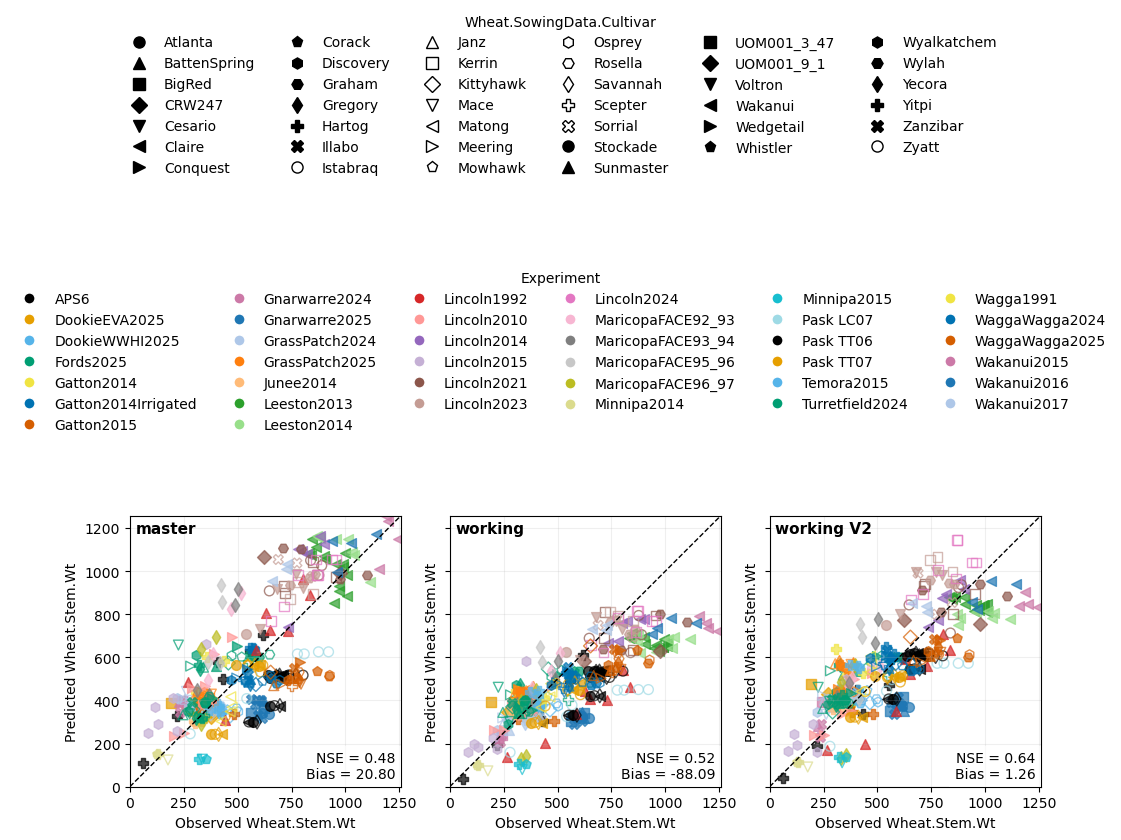

In [17]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.Wt",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by=None
)
plt.show()

## Dead Leaf

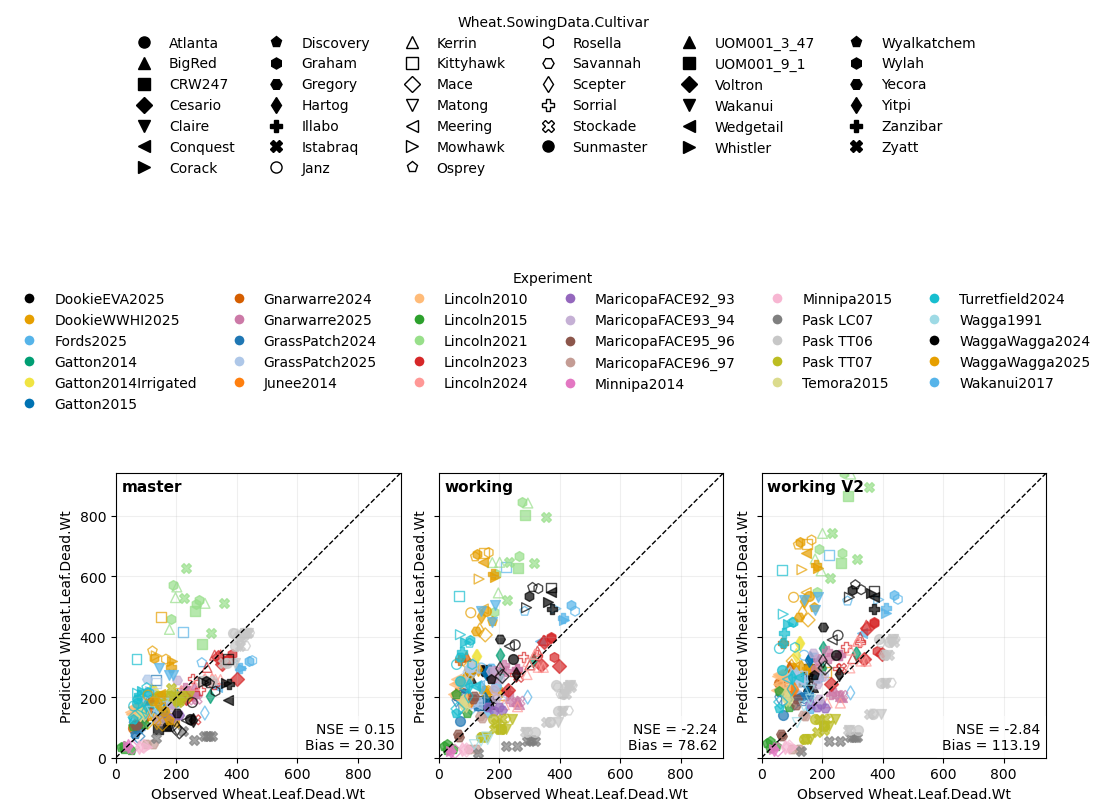

In [18]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.Wt",
    mode='harvest',
    filters=None, #filters = {'Wheat.SowingData.Cultivar':['Meering','Mowhawk']}
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by=None
)
plt.show()

# Growth cycle analysis

## Haun Stage

### obs vs pred daily

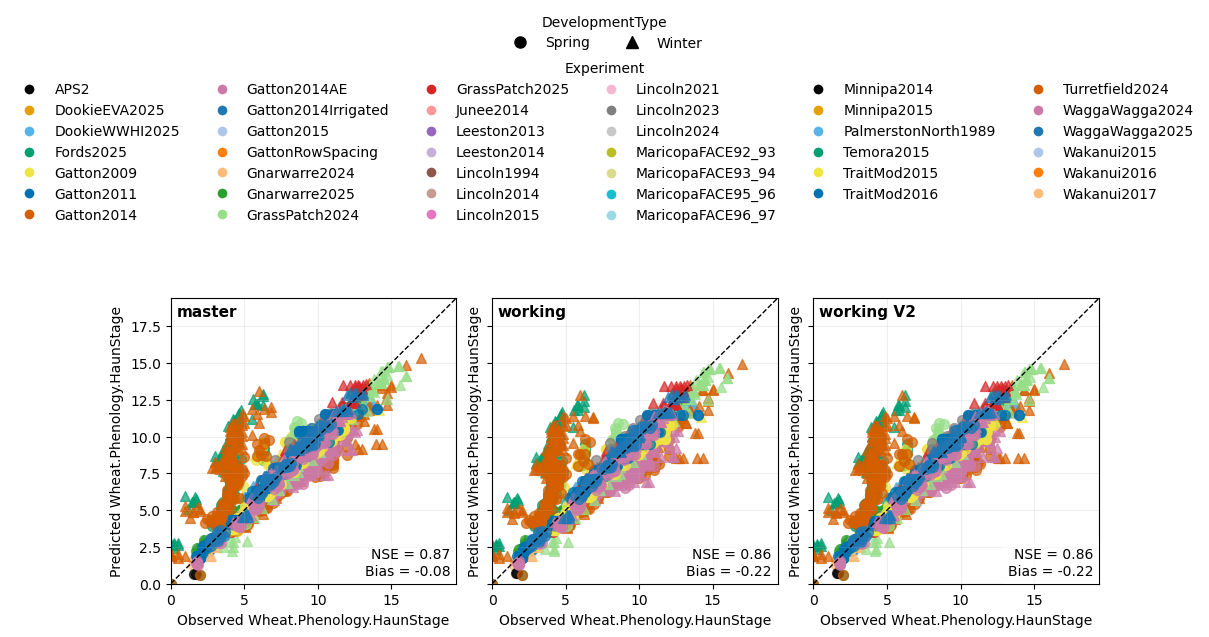

In [19]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Phenology.HaunStage",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by = None
)
plt.show()

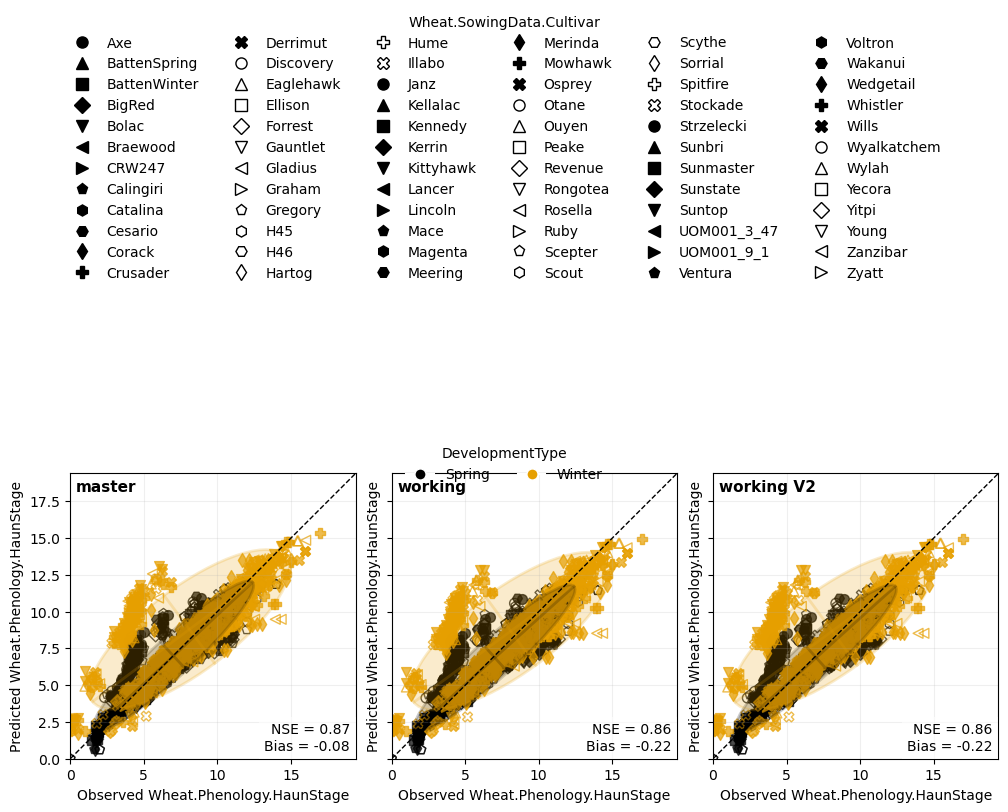

In [20]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Phenology.HaunStage",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Phenology.HaunStage",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="DevelopmentType",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By expt

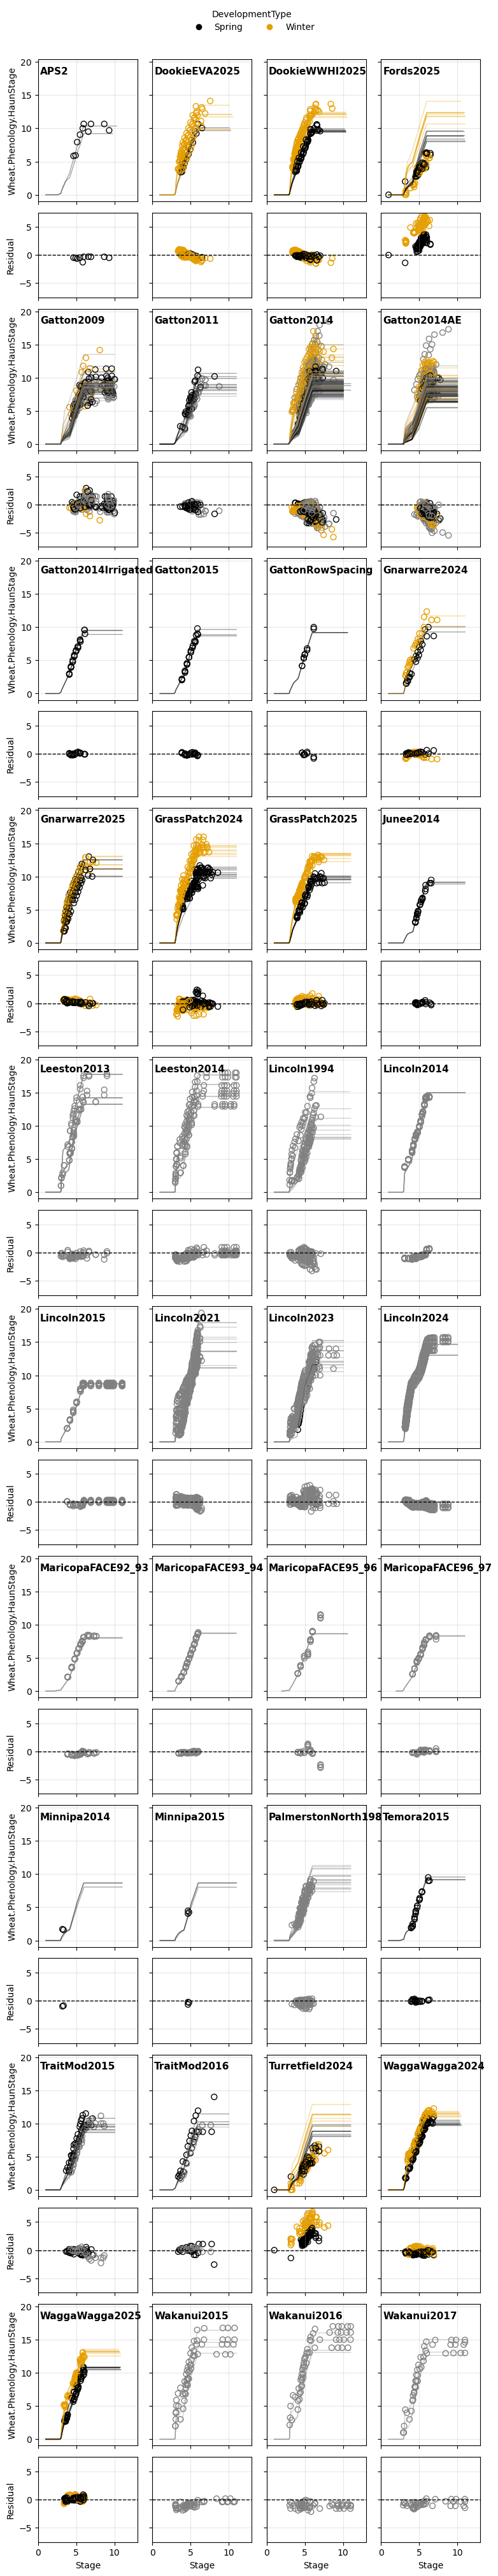

In [22]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Phenology.HaunStage",
    color_by="DevelopmentType",
    marker_by=None,
    panels_by="Experiment",
    filters={"branch": ["working"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## NDVI

### obs vs pred daily 

C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-package

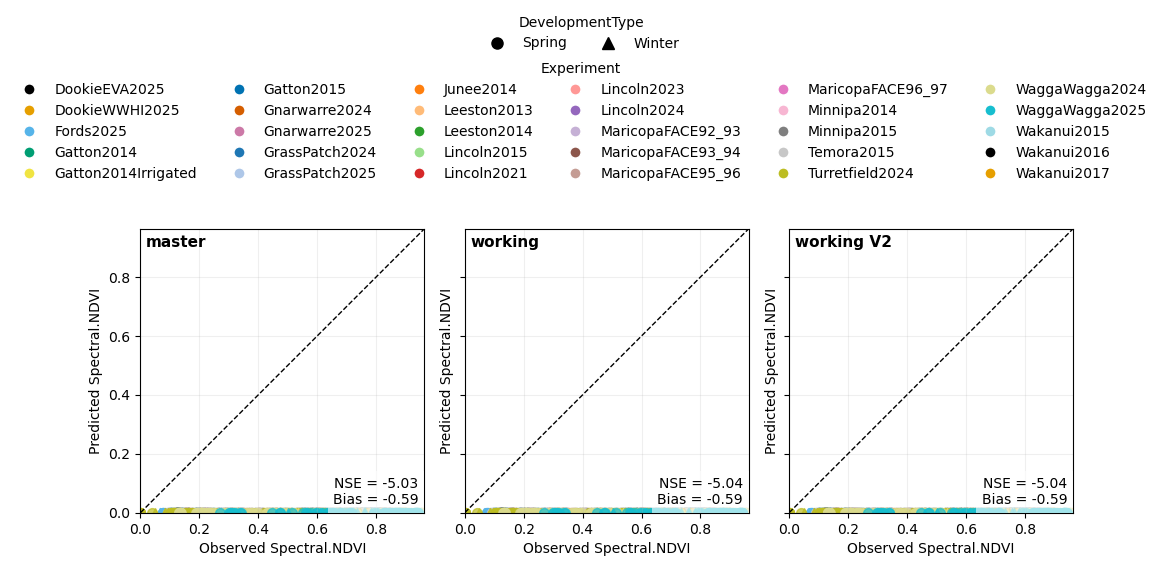

In [23]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Spectral.NDVI",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by =None
)
plt.show()

C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\Lib\site-package

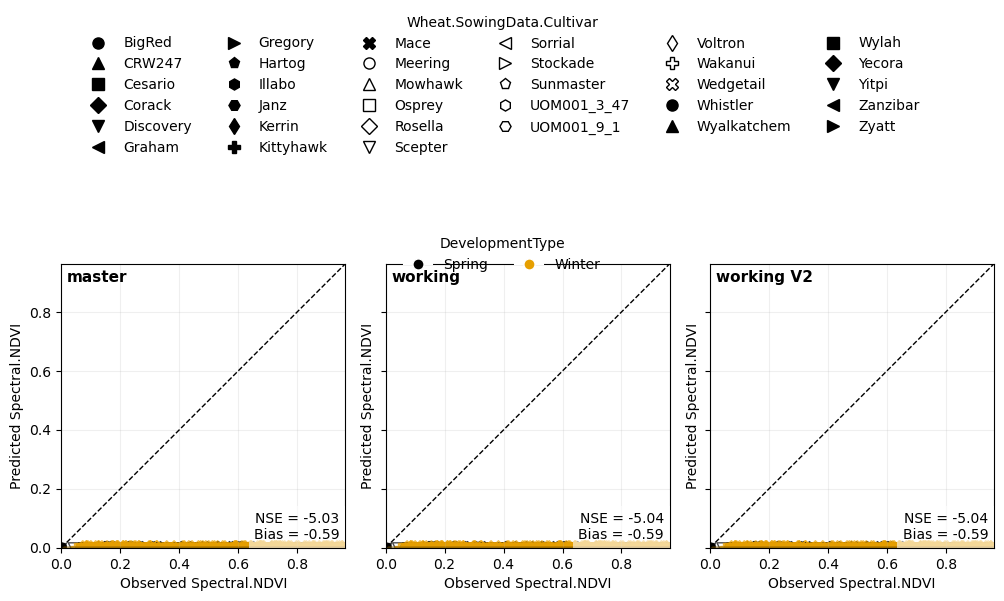

In [24]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Spectral.NDVI",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

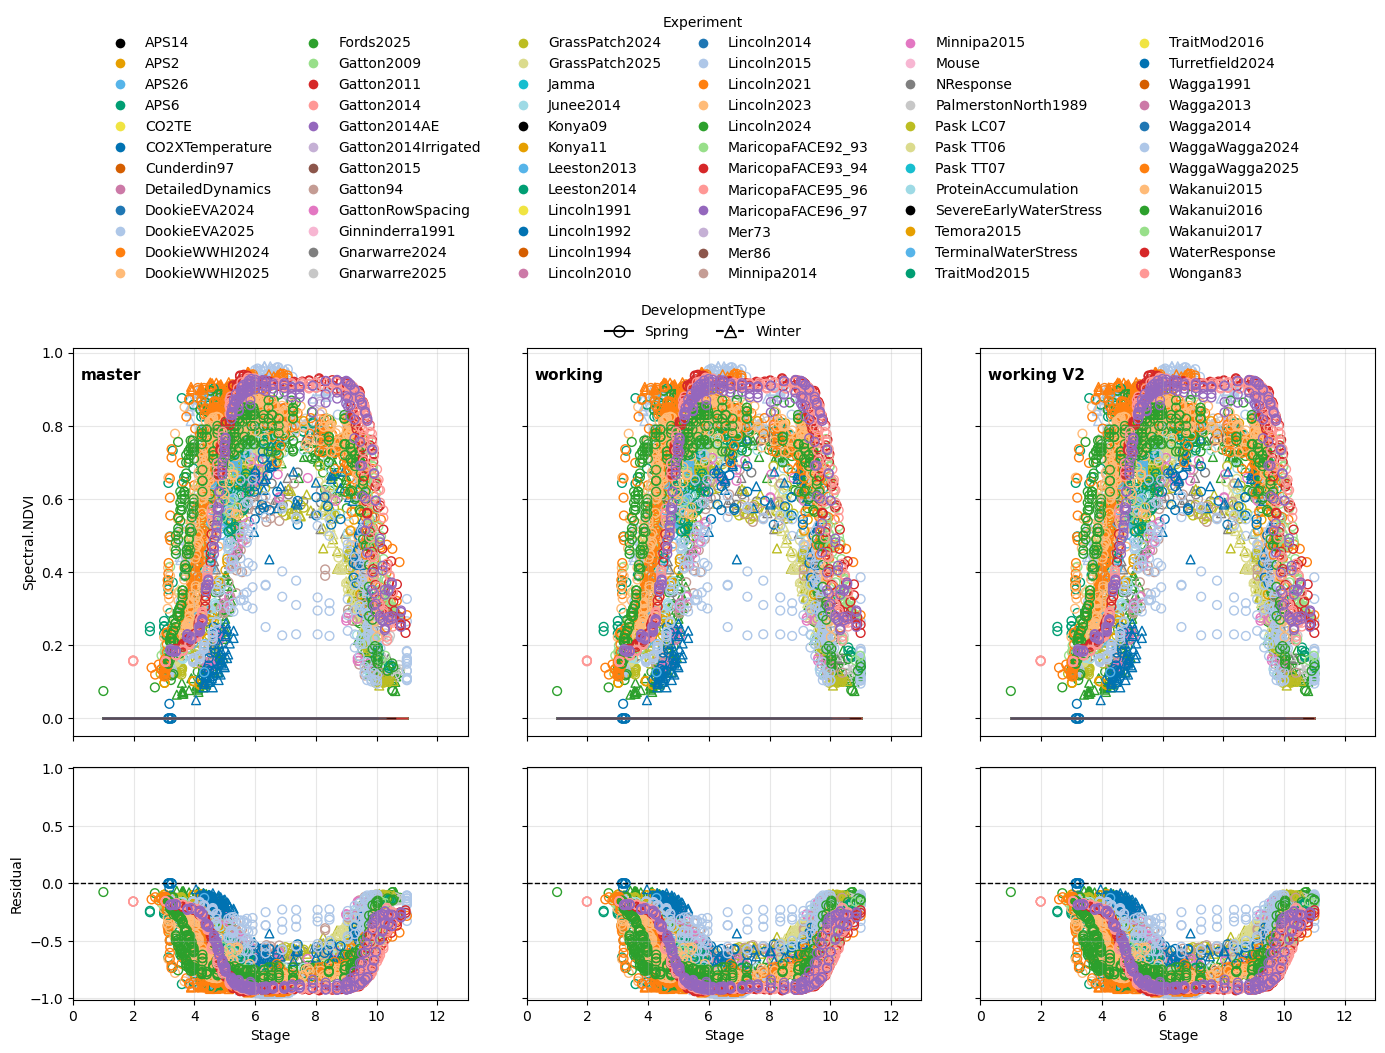

In [25]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Spectral.NDVI",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="DevelopmentType",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Spectral.NDVI",
    color_by="DevelopmentType",
    marker_by=None,
    panels_by="Experiment",
    filters={"branch": ["working V2"]},
            #"ProjectGroup":["GxExM"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## AboveGround Wt

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.Wt",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.Wt",
    color_by="DevelopmentType",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="Experiment",
    filters={"branch": ["master"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## Leaf Live Wt

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.Wt",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.Wt",
    color_by="DevelopmentType",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="Experiment",
    filters={"branch": ["working V2"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

### CHO %

In [ ]:
# plot_stage_timeseries(
#     tidy = tidy,
#     config = CONFIG,
#     variable = "Wheat.Leaf.Live.WSCConc",
#     filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
#     color_by="Experiment",
#     marker_by="Wheat.SowingData.Cultivar",
#     panels_by="branch",
#     max_cols=3,
#     panel_scale=2,
# )

# plt.show()

## Leaf Dead Wt

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.Wt",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.Wt",
    color_by="DevelopmentType",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="Experiment",
    filters={"branch": ["working V2"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

### CHO %

In [ ]:
# plot_stage_timeseries(
#     tidy = tidy,
#     config = CONFIG,
#     variable = "Wheat.Leaf.Dead.WSCConc",
#     filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
#     color_by="Experiment",
#     marker_by="DevelopmentType",
#     panels_by="branch",
#     max_cols=3,
#     panel_scale=2,
# )

# plt.show()

## Stem Wt

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.Wt",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="DevelopmentType",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.Wt",
    color_by="DevelopmentType",
    marker_by="DevelopmentType",
    panels_by="Experiment",
    filters={"branch": ["working V2"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

### WSC %

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.WSCConc",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="DevelopmentType",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

In [ ]:
graph = plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.WSCConc",
    filters={"Experiment": ["Gatton2014","Gatton2014Irrigated","Gatton2015","Junee2014","Temora2015"]},
    color_by="Experiment",
    marker_by="DevelopmentType",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)
graph.savefig("Stem WSC GxExM.jpg")

In [ ]:
# graph = plot_stage_timeseries(
#     tidy = tidy,
#     config = CONFIG,
#     variable = "Wheat.Stem.WSCConc",
#     filters={"ProjectGroup": ["WWHI"]},
#     color_by="Experiment",
#     marker_by="DevelopmentType",
#     panels_by="branch",
#     max_cols=3,
#     panel_scale=2,
# )
# graph.savefig("Stem WSC WWHI.jpg")

## Spike Weight

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.Wt",
    mode="daily",
    #filters={"Experiment": ["Gnarwarre2025"]},
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.Wt",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.Wt",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.Wt",
    color_by="DevelopmentType",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="Experiment",
    filters={"branch": ["working"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

### CHO %

In [ ]:
# plot_stage_timeseries(
#     tidy = tidy,
#     config = CONFIG,
#     variable = "Wheat.Spike.WSCConc",
#     filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
#     color_by="Experiment",
#     marker_by="Wheat.SowingData.Cultivar",
#     panels_by="branch",
#     max_cols=3,
#     panel_scale=2,
# )

# plt.show()

## AboveGround N

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.N",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

In [ ]:
graph = plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.N",
    filters={"Experiment": ["Gatton2014","Gatton2014Irrigated","Gatton2015","Junee2014","Temora2015"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)
graph.savefig("Nuptake GxExM.jpg")

In [ ]:
graph = plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.N",
    filters={"ProjectGroup": ["WWHI"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)
graph.savefig("Nuptake WWHI.jpg")

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.AboveGround.N",
    color_by="DevelopmentType",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="Experiment",
    filters={"branch": ["working V2"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## Leaf Live N

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "DevelopmentType",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.N",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.N",
    color_by="DevelopmentType",
    marker_by="DevelopmentType",
    panels_by="Experiment",
    filters={"branch": ["working V2"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

### NConc

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.NConc",
    color_by="Experiment",
    marker_by="DevelopmentType",
    panels_by="branch",
    filters=None,
    max_cols=4,
    panel_scale=2,
)
plt.show()

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Live.NConc",
    color_by="DevelopmentType",
    marker_by="DevelopmentType",
    panels_by="Experiment",
    filters={'branch':['working V2']},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## Leaf Dead N

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.N",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.N",
    color_by="DevelopmentType",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="Experiment",
    filters={"branch": ["working V2"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

### NConc

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.NConc",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Leaf.Dead.NConc",
    color_by="DevelopmentType",
    marker_by="DevelopmentType",
    panels_by="Experiment",
    filters={'branch':['working V2']},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## Stem N

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.N",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="DevelopmentType",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.N",
    color_by="DevelopmentType",
    marker_by="DevelopmentType",
    panels_by="Experiment",
    filters={"branch": ["working V2"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

### NConc

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.NConc",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Stem.NConc",
    color_by="DevelopmentType",
    marker_by="DevelopmentType",
    panels_by="Experiment",
    filters={'branch':['working V2']},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

## Spike N

### obs vs pred daily 

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "Experiment",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None
)
plt.show()

In [ ]:
plot_obs_pred_by_branch(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.N",
    mode="daily",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by = "DevelopmentType",
    marker_by = "Wheat.SowingData.Cultivar",
    size_by = None,
    show_ellipses=True
)
plt.show()

### All expts

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.N",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.NConc",
    filters=None, #filters={"Experiment": ["DookieWWHI2025"]},
    color_by="Experiment",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="branch",
    max_cols=3,
    panel_scale=2,
)

plt.show()

### By Experiment

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.N",
    color_by="branch",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="Experiment",
    filters=None,
    max_cols=4,
    panel_scale=0.8,
)
plt.show()

In [ ]:
plot_stage_timeseries(
    tidy = tidy,
    config = CONFIG,
    variable = "Wheat.Spike.NConc",
    color_by="DevelopmentType",
    marker_by="Wheat.SowingData.Cultivar",
    panels_by="Experiment",
    filters={"branch": ["working"]},
    max_cols=4,
    panel_scale=0.8,
)
plt.show()